In [ ]:
import torch 
import torch.nn as nn 
import torch.optim as optim

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NeuralNet,self).__init__()                        # super() indicates it to go run the parent's setup first.
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
        #self.sigmoid = nn.Sigmoid()
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))              # input → hidden
        x = self.layer2(x)                         # hidden → output
        return x 

model = NeuralNet(input_size=4, hidden_size=8, output_size=3)
print(model)
print("Total Trainable Parameters: " , sum(p.numel() for p in model.parameters()))

NeuralNet(
  (layer1): Linear(in_features=4, out_features=8, bias=True)
  (layer2): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)
Total Trainable Parameters:  67


In [9]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

iris = load_iris()
X, y = iris.data, iris.target 

print(f"Features: {iris.feature_names}")
print(f"Classes:  {iris.target_names}")
print(f"X shape:  {X.shape}")   # (150, 4)
print(f"y shape:  {y.shape}")   # (150,)

scaler = StandardScaler()                                 #
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  ['setosa' 'versicolor' 'virginica']
X shape:  (150, 4)
y shape:  (150,)

Training samples: 120
Testing samples:  30


In [ ]:
import matplotlib.pyplot as plt

model     = NeuralNet(input_size=4, hidden_size=8, output_size=3)
criterion = nn.CrossEntropyLoss()   # better than MSE for classification
optimizer = optim.Adam(model.parameters(), lr=0.01)

epochs = 200
train_losses  = []
train_accuracy = []

for epoch in range(epochs):
    
    model.train()

    outputs = model(X_train)                               # Forward Pass
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Tracking Accuracy 
    _, predicted = torch.max(outputs, 1)                    # pick highest scoring class → predicted along dimension 1
    correct  = (predicted == y_train).sum().item()          # y_train → count matches → correct
    accuracy = correct / y_train.size(0) * 100              # CrossEntropyLoss uses the logits directly (applies Softmax internally) .torch.max does the argmax step at prediction time

    train_losses.append(loss.item())
    train_accuracy.append(accuracy)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {accuracy:.1f}%")

print(f"\nFinal Training Accuracy: {train_accuracy[-1]:.1f}%")

Epoch   0 | Loss: 1.3734 | Accuracy: 31.7%
Epoch  20 | Loss: 0.7703 | Accuracy: 80.8%
Epoch  40 | Loss: 0.4856 | Accuracy: 81.7%
Epoch  60 | Loss: 0.3160 | Accuracy: 90.8%
Epoch  80 | Loss: 0.2016 | Accuracy: 95.0%
Epoch 100 | Loss: 0.1347 | Accuracy: 96.7%
Epoch 120 | Loss: 0.1018 | Accuracy: 95.8%
Epoch 140 | Loss: 0.0849 | Accuracy: 95.8%
Epoch 160 | Loss: 0.0748 | Accuracy: 96.7%
Epoch 180 | Loss: 0.0683 | Accuracy: 96.7%

Final Training Accuracy: 97.5%


In [11]:
model.eval()   # setting model to evaluation mode

with torch.no_grad():   # no gradients needed for evaluation — saves memory
    test_outputs = model(X_test)
    _, predicted = torch.max(test_outputs, 1)

    correct  = (predicted == y_test).sum().item()
    accuracy = correct / y_test.size(0) * 100

    print(f"Test Accuracy: {accuracy:.1f}%")
    print(f"\nPredictions: {predicted.numpy()}")
    print(f"Actual:      {y_test.numpy()}")

# Class-by-class breakdown
for i, class_name in enumerate(iris.target_names):
    class_mask   = (y_test == i)
    class_correct = (predicted[class_mask] == y_test[class_mask]).sum().item()
    class_total   = class_mask.sum().item()
    print(f"{class_name}: {class_correct}/{class_total} correct")

Test Accuracy: 100.0%

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
Actual:      [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]
setosa: 10/10 correct
versicolor: 9/9 correct
virginica: 11/11 correct


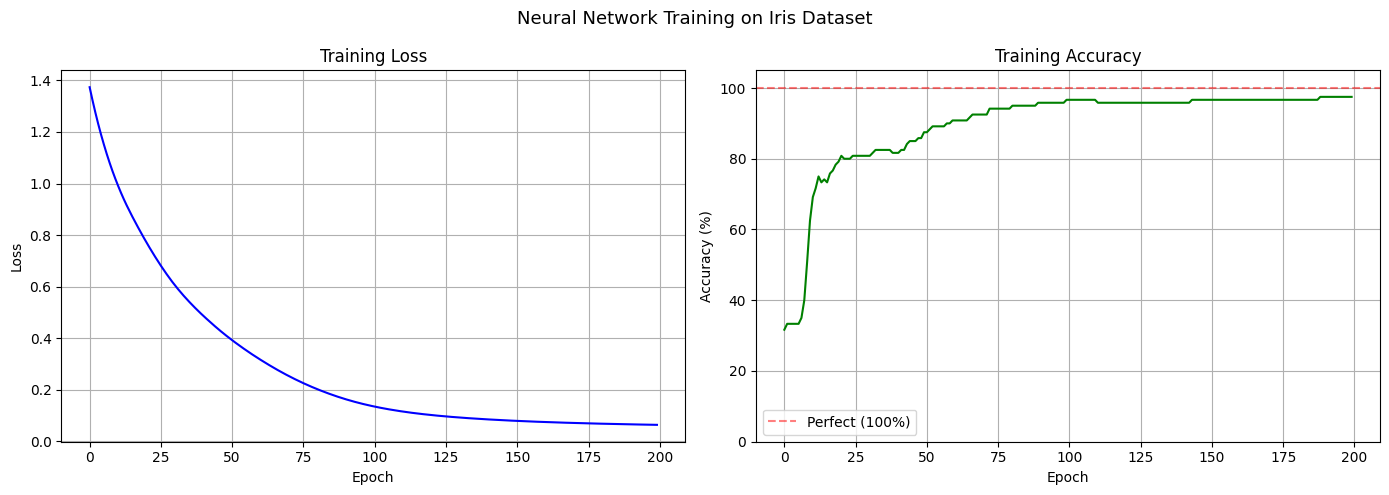

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses, 'b-', linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Accuracy curve
ax2.plot(train_accuracy, 'g-', linewidth=1.5)
ax2.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Perfect (100%)')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training Accuracy")
ax2.set_ylim([0, 105])
ax2.legend()
ax2.grid(True)

plt.suptitle("Neural Network Training on Iris Dataset", fontsize=13)
plt.tight_layout()
plt.show()

DeeperNet(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=8, bias=True)
  (layer3): Linear(in_features=8, out_features=3, bias=True)
  (relu): ReLU()
)
Total Trainable parameters:  [243]

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes:  ['setosa' 'versicolor' 'virginica']
X shape:  (150, 4)
y shape:  (150,)

Training samples: 105
Testing samples:  45
Epoch   0 | Loss: 1.0800 | Accuracy: 35.2%
Epoch  20 | Loss: 0.4896 | Accuracy: 80.0%
Epoch  40 | Loss: 0.2235 | Accuracy: 90.5%
Epoch  60 | Loss: 0.0881 | Accuracy: 95.2%
Epoch  80 | Loss: 0.0610 | Accuracy: 98.1%
Epoch 100 | Loss: 0.0554 | Accuracy: 98.1%
Epoch 120 | Loss: 0.0533 | Accuracy: 98.1%
Epoch 140 | Loss: 0.0524 | Accuracy: 98.1%
Epoch 160 | Loss: 0.0520 | Accuracy: 98.1%
Epoch 180 | Loss: 0.0518 | Accuracy: 98.1%

Final Training Accuracy: 98.1%
Test Accuracy: 100.0%

Predictions: [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1

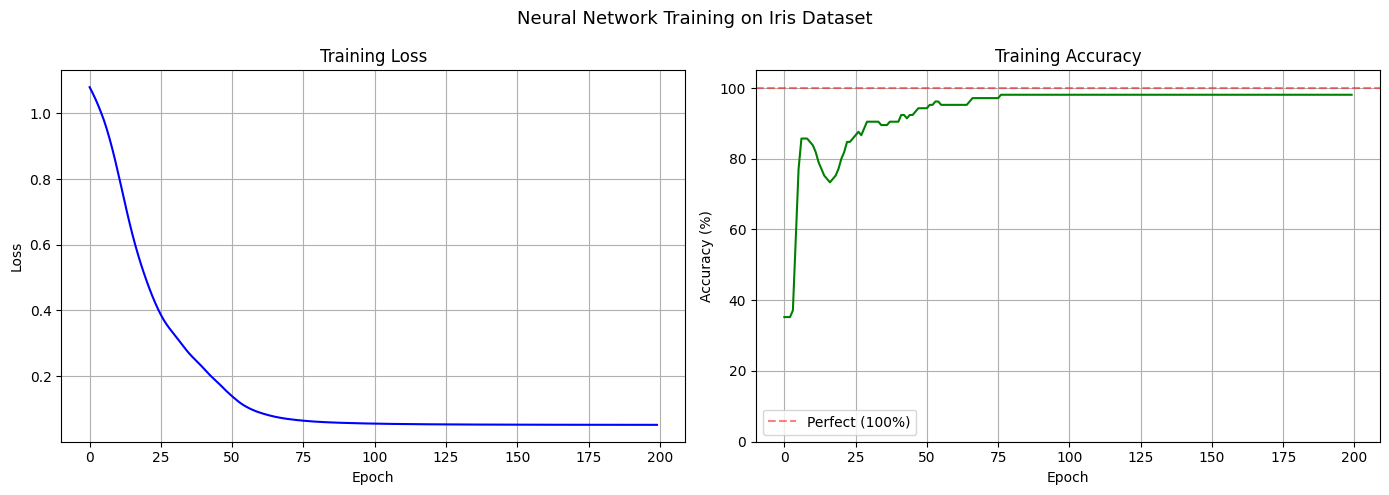

In [29]:
# Adding another layer and code deeperNet class NEW 

class DeeperNet(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, output_size):
        super(DeeperNet, self).__init__()
        self.layer1 = nn.Linear(input_size,   hidden_size1)
        self.layer2 = nn.Linear(hidden_size1, hidden_size2)
        self.layer3 = nn.Linear(hidden_size2, output_size)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.relu(self.layer1(x))
        x = self.relu(self.layer2(x))
        x = self.layer3(x)
        return x

model2 = DeeperNet(input_size=4, hidden_size1=16, hidden_size2=8, output_size=3)
print(model2)
print("Total Trainable parameters: " , [sum(p.numel() for p in model2.parameters())])  # numel() -- is the number of elements

# Load Iris — 150 flowers, 4 features, 3 classes
iris = load_iris()
X, y = iris.data, iris.target

print(f"\nFeatures: {iris.feature_names}")
print(f"Classes:  {iris.target_names}")
print(f"X shape:  {X.shape}")   # (150, 4)
print(f"y shape:  {y.shape}")   # (150,)

scaler = StandardScaler()
X = scaler.fit_transform(X) 

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test  = torch.tensor(X_test,  dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
y_test  = torch.tensor(y_test,  dtype=torch.long)

print(f"\nTraining samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

# Initializing model

model2 = DeeperNet(input_size=4, hidden_size1=16, hidden_size2=8, output_size=3)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model2.parameters(), lr=0.01)

epochs = 200
train_losses2 = []
train_accuracy2 = []

for epoch in range(epochs):
    model2.train()
    outputs = model2(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad() # Deleting the previous gradients memory
    loss.backward()       # Backprop
    optimizer.step()      # Updating the weights and biases

    # Tracking Accuracy
    _, predicted = torch.max(outputs, 1)   # pick class with highest score
    correct  = (predicted == y_train).sum().item()
    accuracy2 = correct / y_train.size(0) * 100

    train_losses2.append(loss.item())
    train_accuracy2.append(accuracy2)

    if epoch % 20 == 0:
        print(f"Epoch {epoch:3d} | Loss: {loss.item():.4f} | Accuracy: {accuracy2:.1f}%")

print(f"\nFinal Training Accuracy: {train_accuracy2[-1]:.1f}%")

# Evaluating the Model
model2.eval()

with torch.no_grad():
    test_outputs2 = model2(X_test)
    _, predicted = torch.max(test_outputs2, 1)

    correct2 = (predicted == y_test).sum().item()
    accuracy2 = correct2 / y_test.size(0) * 100 

    print(f"Test Accuracy: {accuracy2:.1f}%")
    print(f"\nPredictions: {predicted.numpy()}")
    print(f"Actual:      {y_test.numpy()}") 

for i, class_name in enumerate(iris.target_names):
    class_mask   = (y_test == i)
    class_correct = (predicted[class_mask] == y_test[class_mask]).sum().item()
    class_total   = class_mask.sum().item()
    print(f"{class_name}: {class_correct}/{class_total} correct")


#Plotting to see the training process

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
ax1.plot(train_losses2, 'b-', linewidth=1.5)
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training Loss")
ax1.grid(True)

# Accuracy curve
ax2.plot(train_accuracy2, 'g-', linewidth=1.5)
ax2.axhline(y=100, color='red', linestyle='--', alpha=0.5, label='Perfect (100%)')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training Accuracy")
ax2.set_ylim([0, 105])
ax2.legend()
ax2.grid(True)

plt.suptitle("Neural Network Training on Iris Dataset", fontsize=13)
plt.tight_layout()
plt.show()
